### Transformers (BETO) for classification

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
import optuna
from transformers import TrainerCallback
class MyOptunaCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        control.should_training_stop = True
        return control

In [2]:
def model_init():
    return BertForSequenceClassification.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased", num_labels=4)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [3]:
model = BertForSequenceClassification.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased", num_labels=4)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Análisis de datos

In [4]:
df = pd.read_csv("../data/dataset.csv", sep=';', encoding='ISO-8859-1')

In [5]:
df.head()

,category,text
0,7,Nuestros clientes son diversos y cada uno tien...
1,7,Nos enfocamos en varios tipos de clientes. Nue...
2,6,Nuestro objetivo son las pequeñas empresas que...
3,6,Nos centramos en los turistas que buscan exper...
4,4,"Generalmente, trabajamos con entidades guberna..."


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\juanc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


            mean  median  min  max        std
category                                     
1         13.104    12.0    3   29   5.425186
4         13.096    13.0    7   25   3.504430
6         22.216    20.0   10   37   6.452786
7         41.048    38.0   23   75  11.252853
   category  mode
0         1    10
1         4    11
2         6    17
3         7    38


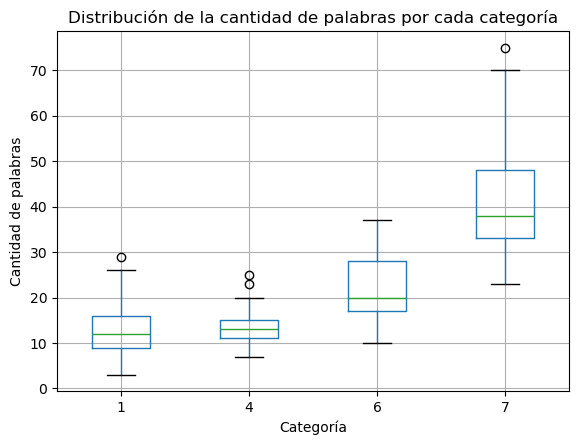

In [6]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
import matplotlib.pyplot as plt
import numpy as np

df['text'] = df['text'].astype(str)

df['word_count'] = df['text'].apply(lambda x: len(word_tokenize(x)))

stats_df = df.groupby('category')['word_count'].agg(['mean', 'median', 'min', 'max', 'std'])
print(stats_df)

mode_df = df.groupby('category')['word_count'].apply(lambda x: x.mode()[0]).reset_index()
mode_df.columns = ['category', 'mode']
print(mode_df)

df.boxplot(column='word_count', by='category')
plt.title('Distribución de la cantidad de palabras por cada categoría')
plt.suptitle('') # Eliminar el título automático
plt.xlabel('Categoría')  # Título del eje X
plt.ylabel('Cantidad de palabras')  # Título del eje Y
plt.show()


In [7]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

df['text'] = df['text'].astype(str)

stop_words = set(stopwords.words('spanish'))

def count_words_and_stopwords(text):
    words = word_tokenize(text)
    word_count = len([word for word in words if word.casefold() not in stop_words])
    stopwords_in_text = [word for word in words if word.casefold() in stop_words]
    return word_count, stopwords_in_text

df['word_count'], df['stopwords_in_text'] = zip(*df['text'].apply(count_words_and_stopwords))

stats_df = df.groupby('category')['word_count'].agg(['mean', 'median', 'min', 'max', 'std'])

mode_df = df.groupby('category')['word_count'].apply(lambda x: x.mode()[0]).reset_index()
mode_df.columns = ['category', 'mode']

print("Stopwords eliminadas: ", df['stopwords_in_text'].explode().unique())


Stopwords eliminadas:  ['Nuestros' 'son' 'y' 'uno' 'tiene' 'sus' 'nos' 'a' 'de' 'quienes' 'la'
 'nuestros' 'las' 'otro' 'por' 'nuestra' 'Por' 'también' 'los' 'al'
 'nuestras' 'el' 'que' 'Nos' 'en' 'su' 'están' 'un' 'para' 'Nuestro' 'una'
 'Este' 'nuestro' 'con' 'del' 'estamos' 'más' 'no' 'hemos' 'estos'
 'tenemos' 'Nuestra' 'está' 'Las' 'Los' 'o' 'Estos' 'todos' 'sin' 'serían'
 'El' 'durante' 'es' 'pero' 'Tenemos' 'se' 'Y' 'A' 'También' 'En' 'este'
 'será' 'Como' 'somos' 'sobre' 'hay' 'estado' 'muchos' 'tienen' 'estén'
 'como' 'os' 'Estamos' 'Nuestras' 'tanto' 'e' 'otros' 'mucho' 'donde'
 'sean' 'ellos' nan 'algo' 'todo' 'les' 'esta' 'Uno' 'Hasta' 'ya' 'sea'
 'desde' 'TI' 'entre' 'estas' 'qué' 'serán' 'antes']


            mean  median  min  max       std
category                                    
1          7.544     7.0    3   15  2.841240
4          7.304     7.0    4   13  2.052630
6         12.744    12.0    6   22  3.719834
7         24.128    23.0   13   44  6.610080
   category  mode
0         1     6
1         4     6
2         6    10
3         7    19


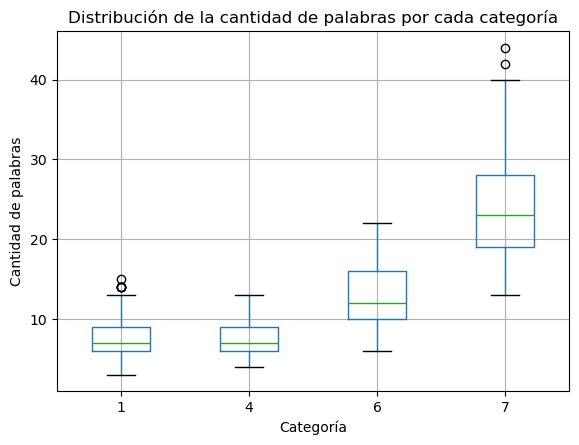

In [8]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

df['text'] = df['text'].astype(str)

stop_words = set(stopwords.words('spanish'))

df['word_count'] = df['text'].apply(lambda x: len([word for word in word_tokenize(x) if word.casefold() not in stop_words]))

stats_df = df.groupby('category')['word_count'].agg(['mean', 'median', 'min', 'max', 'std'])
print(stats_df)

mode_df = df.groupby('category')['word_count'].apply(lambda x: x.mode()[0]).reset_index()
mode_df.columns = ['category', 'mode']
print(mode_df)

df.boxplot(column='word_count', by='category')
plt.title('Distribución de la cantidad de palabras por cada categoría')
plt.suptitle('')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de palabras')
plt.show()

In [9]:
# Definir una función para extraer las palabras clave
def extract_keywords(text, num_keywords):
    vectorizer = TfidfVectorizer(stop_words=stopwords.words('spanish'))
    tfidf_matrix = vectorizer.fit_transform(text)
    words = vectorizer.get_feature_names_out()
    sums = tfidf_matrix.sum(axis=0)
    data = []
    for col, word in enumerate(words):
        data.append( (word, sums[0,col] ))
    ranking = pd.DataFrame(data, columns=['word','rank'])
    words_df = ranking.sort_values('rank', ascending=False)
    return words_df['word'].head(num_keywords)

# Aplicar la función a cada categoría
df['text'] = df['text'].astype(str)
keywords_per_category = df.groupby('category')['text'].apply(lambda texts: extract_keywords(texts, 10))
print(keywords_per_category)

category     
1         277       servicios
          21              aún
          38         clientes
          197       ofrecemos
          287      trabajando
          298        variedad
          37          cliente
          286         todavía
          8            amplia
          18           aunque
4         273       servicios
          36           buscan
          224        personas
          103        empresas
          236       productos
          76       destinados
          272        servicio
          59     construcción
          204       ofrecemos
          194       necesitan
6         82           buscan
          510       servicios
          89          calidad
          213        empresas
          447       productos
          373       necesitan
          217       enfocamos
          440       principal
          23             alta
          419        personas
7         126          buscan
          326        empresas
          672       produc

### Datos

In [10]:
category_count = df['category'].value_counts()
categories = category_count.index
df['encoded_text'] = df['category'].astype('category').cat.codes

data_texts = df['text'].to_list()
data_labels = df['encoded_text'].to_list()

train_texts, val_texts, train_labels, val_labels = train_test_split(data_texts, data_labels, random_state = 1800)

In [11]:
# Cuenta de cada categoría
category_count = df['category'].value_counts()

# Imprime el conteo de cada categoría
print(category_count)

category
7    125
6    125
4    125
1    125
Name: count, dtype: int64


In [12]:
print("Conjunto de datos de entrenamiento:", len(train_texts))
print("Conjunto de datos de prueba:", len(val_texts))

count_0 = train_labels.count(0)
count_1 = train_labels.count(1)
count_2 = train_labels.count(2)
count_3 = train_labels.count(3)

print("")
print("Datos de entrenamiento:")
print("Nota 1:", count_0)
print("Nota 4:", count_1)
print("Nota 6:", count_2)
print("Nota 7:", count_3)

Conjunto de datos de entrenamiento: 375
Conjunto de datos de prueba: 125

Datos de entrenamiento:
Nota 1: 92
Nota 4: 92
Nota 6: 93
Nota 7: 98


In [13]:
count_t_0 = val_labels.count(0)
count_t_1 = val_labels.count(1)
count_t_2 = val_labels.count(2)
count_t_3 = val_labels.count(3)
print("")
print("Datos de prueba:")
print("Nota 1:", count_t_0)
print("Nota 4:", count_t_1)
print("Nota 6:", count_t_2)
print("Nota 7:", count_t_3)


Datos de prueba:
Nota 1: 33
Nota 4: 33
Nota 6: 32
Nota 7: 27


In [14]:
tokenizer = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, return_tensors="pt")
val_encodings = tokenizer(val_texts, truncation=True, padding=True, return_tensors="pt")

train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels)

In [15]:
from torch.utils.data import Dataset

class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextClassificationDataset(train_encodings, train_labels)
val_dataset = TextClassificationDataset(val_encodings, val_labels)

In [16]:
import numpy as np
import time

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-4, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 1,5)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32, 64])

# Otros hiperparámetros:
#     seed = trial.suggest_int("seed", 1, 40)
#     weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
#     warmup_steps = trial.suggest_int("warmup_steps", 0, 1000)
#     eval_steps = trial.suggest_int("eval_steps", 10, 100)

    args = TrainingArguments(
        output_dir="results",
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_train_batch_size,
        logging_dir="logs",
        #evaluation_strategy="epoch",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    print(eval_metrics)

    return eval_metrics["eval_loss"]

start = time.time()

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=10)
print("Tiempo de ejecución:", time.time() - start, "segundos")

[I 2025-07-05 19:41:44,698] A new study created in memory with name: no-name-f90bfb2a-7029-4388-8474-8018913aff3d
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Step,Training Loss


C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


[I 2025-07-05 19:43:15,471] Trial 0 finished with value: 1.2858635187149048 and parameters: {'learning_rate': 1.0882607843181213e-06, 'num_train_epochs': 5, 'per_device_train_batch_size': 32}. Best is trial 0 with value: 1.2858635187149048.


{'eval_loss': 1.2858635187149048, 'eval_accuracy': 0.512, 'eval_f1': 0.49720666873371006, 'eval_precision': 0.6066671737403445, 'eval_recall': 0.5170191498316499, 'eval_runtime': 1.1678, 'eval_samples_per_second': 107.041, 'eval_steps_per_second': 13.701, 'epoch': 5.0}


...

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Step,Training Loss


C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


[I 2025-07-05 19:53:43,478] Trial 9 finished with value: 0.8458914756774902 and parameters: {'learning_rate': 1.95164394004593e-06, 'num_train_epochs': 2, 'per_device_train_batch_size': 64}. Best is trial 3 with value: 0.43084728717803955.


{'eval_loss': 0.8458914756774902, 'eval_accuracy': 0.92, 'eval_f1': 0.9227752852862425, 'eval_precision': 0.924404761904762, 'eval_recall': 0.9230587121212122, 'eval_runtime': 1.3247, 'eval_samples_per_second': 94.364, 'eval_steps_per_second': 12.079, 'epoch': 2.0}
Tiempo de ejecución: 718.7983047962189 segundos


In [17]:
# usar k cross fold validation con estos parámetros
study.best_params

{'learning_rate': 6.408100597438174e-05,
 'num_train_epochs': 4,
 'per_device_train_batch_size': 8}

In [18]:
resumen = study.trials_dataframe().drop(['state','datetime_start','datetime_complete','duration','number'], axis=1)
resumen

,value,params_learning_rate,params_num_train_epochs,params_per_device_train_batch_size
0,1.285864,0.000001,5,32
1,0.951560,0.000033,1,64
2,0.747282,0.000006,3,64
3,0.430847,0.000064,4,8
4,0.505662,0.000002,4,16
5,0.929374,0.000073,1,64
6,0.608777,0.000013,2,32
7,0.656482,0.000005,4,64
8,0.845424,0.000021,4,8
9,0.845891,0.000002,2,64


In [19]:
optuna.visualization.plot_optimization_history(study)

In [20]:
optuna.visualization.plot_param_importances(study)

In [21]:
from transformers import pipeline

save_directory_optuna = "/saved_models/optuna"
model.save_pretrained(save_directory_optuna)
tokenizer.save_pretrained(save_directory_optuna)
tokenizer_fine_tuned_optuna = BertTokenizer.from_pretrained(save_directory_optuna)
model_fine_tuned_optuna = BertForSequenceClassification.from_pretrained(save_directory_optuna)

model_optuna = BertForSequenceClassification.from_pretrained(save_directory_optuna)
tokenizer_optuna = BertTokenizer.from_pretrained(save_directory_optuna)

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



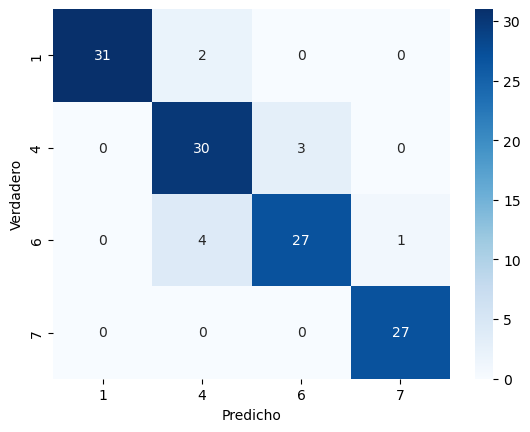

In [22]:
args = TrainingArguments(
    output_dir="results",
)

trainer_optuna = Trainer(
    model=model_optuna,
    args=args,
)

# predicciones en el conjunto de validación
predictions = trainer_optuna.predict(val_dataset)

predicted_classes = np.argmax(predictions.predictions, axis=-1)

true_classes = val_labels.tolist()  # actualiza esto si tus etiquetas están almacenadas de manera diferente


# Ahora puedes crear la matriz de confusión utilizando sklearn
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categories = [1, 4, 6, 7]

cm_1 = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm_1, annot=True, fmt='g', cmap='Blues', xticklabels=categories, yticklabels=categories)

plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

# K-fold Cross-Validation

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

In [24]:
study.best_params

{'learning_rate': 6.408100597438174e-05,
 'num_train_epochs': 4,
 'per_device_train_batch_size': 8}

In [26]:
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1000)

meticas_fold = []
folds = [1,2,3,4,5]

best_params = study.best_params
learning_rate = best_params["learning_rate"]
num_train_epochs = best_params["num_train_epochs"]
per_device_train_batch_size = best_params["per_device_train_batch_size"]
# weight_decay = best_params["weight_decay"]

start_2 = time.time()

for fold, (train_indices, val_indices) in enumerate(kfold.split(data_texts, data_labels)):

    # Dividir los datos en los conjuntos de entrenamiento y validación para este fold
    train_texts_kfold, val_texts_kfold = np.array(data_texts)[train_indices].tolist(), np.array(data_texts)[val_indices].tolist()
    train_labels_kfold, val_labels_kfold = np.array(data_labels)[train_indices].tolist(), np.array(data_labels)[val_indices].tolist()



    # Tokenizar los textos de entrenamiento y validación
    train_encodings_kfold = tokenizer(train_texts_kfold, truncation=True, padding=True, return_tensors="pt")
    val_encodings_kfold = tokenizer(val_texts_kfold, truncation=True, padding=True, return_tensors="pt")

    # Convertir las etiquetas de entrenamiento y validación en tensores
    train_labels_kfold = torch.tensor(train_labels_kfold)
    val_labels_kfold = torch.tensor(val_labels_kfold)

    # Crear los datasets de entrenamiento y validación para este fold
    train_dataset_kfold = TextClassificationDataset(train_encodings_kfold, train_labels_kfold)
    val_dataset_kfold = TextClassificationDataset(val_encodings_kfold, val_labels_kfold)

    # Entrenar el modelo con los hiperparámetros óptimos
    args = TrainingArguments(
        output_dir=f"results_fold_{fold}",
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_train_batch_size,
        logging_dir=f"logs_fold_{fold}",
        #evaluation_strategy="steps",
    )
# weight_decay=weight_decay,
    trainer = Trainer(
        model=model_init(),
        args=args,
        train_dataset=train_dataset_kfold,
        eval_dataset=val_dataset_kfold,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_metrics = trainer.evaluate()


    print(eval_metrics)
    meticas_fold.append(eval_metrics)

print("Tiempo de ejecución:", time.time() - start_2, "segundos")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



Step,Training Loss


C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



{'eval_loss': 0.18548722565174103, 'eval_accuracy': 0.94, 'eval_f1': 0.9379206469821971, 'eval_precision': 0.9410535117056856, 'eval_recall': 0.9397581585081586, 'eval_runtime': 1.0182, 'eval_samples_per_second': 98.212, 'eval_steps_per_second': 12.768, 'epoch': 4.0}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



...

{'eval_loss': 0.4759373962879181, 'eval_accuracy': 0.92, 'eval_f1': 0.9193621090476577, 'eval_precision': 0.9239550679205852, 'eval_recall': 0.9162374981340499, 'eval_runtime': 1.1572, 'eval_samples_per_second': 86.418, 'eval_steps_per_second': 11.234, 'epoch': 4.0}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



Step,Training Loss


C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

C:\Users\juanc\AppData\Local\Temp\ipykernel_23444\132499124.py:10: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



{'eval_loss': 0.4360981285572052, 'eval_accuracy': 0.92, 'eval_f1': 0.9242857142857143, 'eval_precision': 0.9242857142857143, 'eval_recall': 0.9242857142857143, 'eval_runtime': 1.4278, 'eval_samples_per_second': 70.039, 'eval_steps_per_second': 9.105, 'epoch': 4.0}
Tiempo de ejecución: 699.2483596801758 segundos


In [27]:
resultados_metricas = pd.DataFrame({'Metricas': meticas_fold, 'Folds': folds})
for i in range(len(resultados_metricas)):
    print("Fold", i + 1)
    print(resultados_metricas["Metricas"][i])
    print("_______________________________________________________________________________________________________________")


Fold 1
{'eval_loss': 0.18548722565174103, 'eval_accuracy': 0.94, 'eval_f1': 0.9379206469821971, 'eval_precision': 0.9410535117056856, 'eval_recall': 0.9397581585081586, 'eval_runtime': 1.0182, 'eval_samples_per_second': 98.212, 'eval_steps_per_second': 12.768, 'epoch': 4.0}
_______________________________________________________________________________________________________________
Fold 2
{'eval_loss': 0.23225337266921997, 'eval_accuracy': 0.95, 'eval_f1': 0.9497437918801734, 'eval_precision': 0.9552419354838709, 'eval_recall': 0.9475931677018634, 'eval_runtime': 1.1562, 'eval_samples_per_second': 86.488, 'eval_steps_per_second': 11.243, 'epoch': 4.0}
_______________________________________________________________________________________________________________
Fold 3
{'eval_loss': 0.3294433653354645, 'eval_accuracy': 0.94, 'eval_f1': 0.9333595387840671, 'eval_precision': 0.9350368675311467, 'eval_recall': 0.9331501831501832, 'eval_runtime': 1.1198, 'eval_samples_per_second': 89.301,